In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [25]:
path_all = "C:/Users/User/Documents/Sooth_Features_Extraction_plat/TrainSaveAllData_CNNencdec_both_2025-0720-223600/"
path_train = os.path.join(path_all, "csv_data_best_train")
path_val = os.path.join(path_all, "csv_data_best_val")
path_test = os.path.join(path_all, "csv_data_best_test")

In [66]:
#Load and Process One Sample
def process_sample(gt_fv_path, pred_fv_path, gt_t_path, pred_t_path=None):
    gt_fv = pd.read_csv(gt_fv_path, header=None).values
    pred_fv = pd.read_csv(pred_fv_path, header=None).values
    gt_t = pd.read_csv(gt_t_path, header=None).values
    pred_t = pd.read_csv(pred_t_path, header=None).values if pred_t_path else None

    # Row with max t
    max_idx = np.unravel_index(np.argmax(gt_t), gt_t.shape)
    row_idx = max_idx[0]

    sample_stats = {
        'full': {
            'gt_fv': gt_fv.flatten(),
            'pred_fv': pred_fv.flatten(),
            'gt_t': gt_t.flatten(),
            'pred_t': pred_t.flatten() if pred_t is not None else None,
        },
        'row': {
            'gt_fv': gt_fv[row_idx, :],
            'pred_fv': pred_fv[row_idx, :],
            'gt_t': gt_t[row_idx, :],
            'pred_t': pred_t[row_idx, :] if pred_t is not None else None,
        },
        'row_index': row_idx
    }
    return sample_stats

#Error Metrics Calculation
def compute_metrics(gt, pred):
    mse = mean_squared_error(gt, pred)
    mae = mean_absolute_error(gt, pred)
    rel_err = np.mean(np.abs(gt - pred) / (gt + 1e-8))
    r2 = r2_score(gt, pred)
    return mse, mae, rel_err * 100, r2

#Accumulate Dataset Statistics
def process_dataset(data_dir, dataset_name):
    all_metrics = {
        'fv_full': [], 'fv_row': [],
        't_full': [], 't_row': [],
    }

    for fname in sorted(os.listdir(data_dir)):
        if 'gt_Fv' not in fname:
            continue
        sample_id = fname.split('_')[0]
        gt_fv = os.path.join(data_dir, f"{sample_id}_gt_Fv_{dataset_name}.csv")
        pred_fv = os.path.join(data_dir, f"{sample_id}_pred_Fv_{dataset_name}.csv")
        gt_t = os.path.join(data_dir, f"{sample_id}_gt_T_{dataset_name}.csv")
        pred_t = os.path.join(data_dir, f"{sample_id}_pred_T_{dataset_name}.csv")

        try:
            stats = process_sample(gt_fv, pred_fv, gt_t, pred_t)
        except Exception as e:
            print(f"Failed on {sample_id}: {e}")
            continue

        for level in ['full', 'row']:
            all_metrics['fv_' + level].append(compute_metrics(stats[level]['gt_fv'], stats[level]['pred_fv']))
            if stats[level]['pred_t'] is not None:
                all_metrics['t_' + level].append(compute_metrics(stats[level]['gt_t'], stats[level]['pred_t']))

    return all_metrics

#Plotting and Tables
def summarize_metrics(metrics, label):
    def avg_std(metric_list):
        arr = np.array(metric_list)
        return np.mean(arr, axis=0), np.std(arr, axis=0)

    for key in metrics:
        mean_vals, std_vals = avg_std(metrics[key])
        metric_names = ["MSE", "MAE", "RelErr (%)", "R²"]
        print(f"\n[{label}] {key.upper()} Metrics (mean ± std):")
        for name, mean, std in zip(metric_names, mean_vals, std_vals):
            print(f"  {name:12s}: {mean:.5f} ± {std:.5f}")

#dot plot for MAE
def plot_mae_dotplot(mae_train, mae_val, mae_test, title="Per-Sample MAE Dot Plot"):
    plt.figure(figsize=(12, 6))
    
    # Plot each group
    plt.scatter(range(len(mae_train)), mae_train, label='Train', color='#5276B8', alpha=0.6)
    plt.scatter(np.arange(len(mae_val)) + len(mae_train), mae_val, label='Validation', color='#6FB852', alpha=0.6)
    plt.scatter(np.arange(len(mae_test)) + len(mae_train) + len(mae_val), mae_test, label='Test', color='#ECA62F', alpha=0.6)
    
    # Optional horizontal lines for group means
    plt.axhline(np.mean(mae_train), color='blue', linestyle='--', linewidth=1, label='Train Mean')
    plt.axhline(np.mean(mae_val), color='green', linestyle='--', linewidth=1, label='Val Mean')
    plt.axhline(np.mean(mae_test), color='orange', linestyle='--', linewidth=1, label='Test Mean')

    plt.xlabel("Sample Index (Train → Val → Test)")
    plt.ylabel("Mean Absolute Error (MAE)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#Error Distributions and Plots
def plot_error_distributions(all_errors, title_prefix):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    fv_errors = np.array([pred - gt for gt, pred, *_ in all_errors['fv_full']])
    t_errors = np.array([pred - gt for gt, pred, *_ in all_errors['t_full'] if pred is not None])

    sns.histplot(fv_errors, bins=100, ax=axs[0, 0], kde=True)
    axs[0, 0].set_title(f"{title_prefix} Fv Errors")

    sns.boxplot(fv_errors, ax=axs[0, 1], orient='h')
    axs[0, 1].set_title(f"{title_prefix} Fv Boxplot")

    if len(t_errors) > 0:
        sns.histplot(t_errors, bins=100, ax=axs[1, 0], kde=True)
        axs[1, 0].set_title(f"{title_prefix} T Errors")

        sns.boxplot(t_errors, ax=axs[1, 1], orient='h')
        axs[1, 1].set_title(f"{title_prefix} T Boxplot")

    plt.tight_layout()
    plt.show()





[TRAIN] FV_FULL Metrics (mean ± std):
  MSE         : 0.00002 ± 0.00001
  MAE         : 0.00174 ± 0.00034
  RelErr (%)  : 4007747.39695 ± 156693.05020
  R²          : 0.99797 ± 0.00102

[TRAIN] FV_ROW Metrics (mean ± std):
  MSE         : 0.00006 ± 0.00010
  MAE         : 0.00308 ± 0.00130
  RelErr (%)  : 3787324.89824 ± 1461240.93452
  R²          : 0.96503 ± 0.11792

[TRAIN] T_FULL Metrics (mean ± std):
  MSE         : 0.00014 ± 0.00012
  MAE         : 0.00278 ± 0.00045
  RelErr (%)  : 9342452.57775 ± 1064566.89164
  R²          : 0.99691 ± 0.00271

[TRAIN] T_ROW Metrics (mean ± std):
  MSE         : 0.00065 ± 0.00090
  MAE         : 0.00635 ± 0.00300
  RelErr (%)  : 7107929.92736 ± 697542.19080
  R²          : 0.98885 ± 0.01655

[VAL] FV_FULL Metrics (mean ± std):
  MSE         : 0.00002 ± 0.00001
  MAE         : 0.00177 ± 0.00035
  RelErr (%)  : 4016564.51640 ± 163303.97242
  R²          : 0.99789 ± 0.00122

[VAL] FV_ROW Metrics (mean ± std):
  MSE         : 0.00007 ± 0.00011
  MA

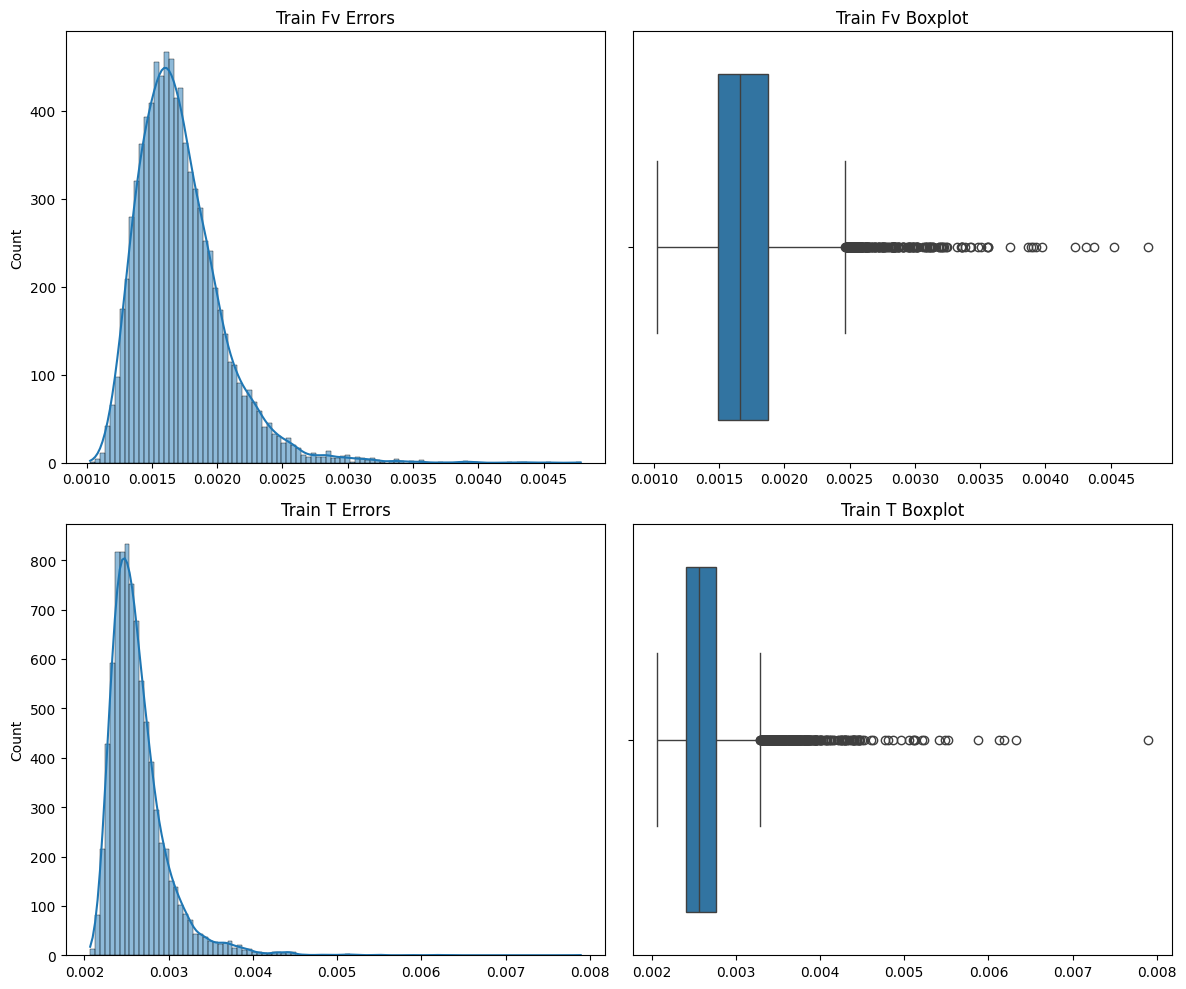

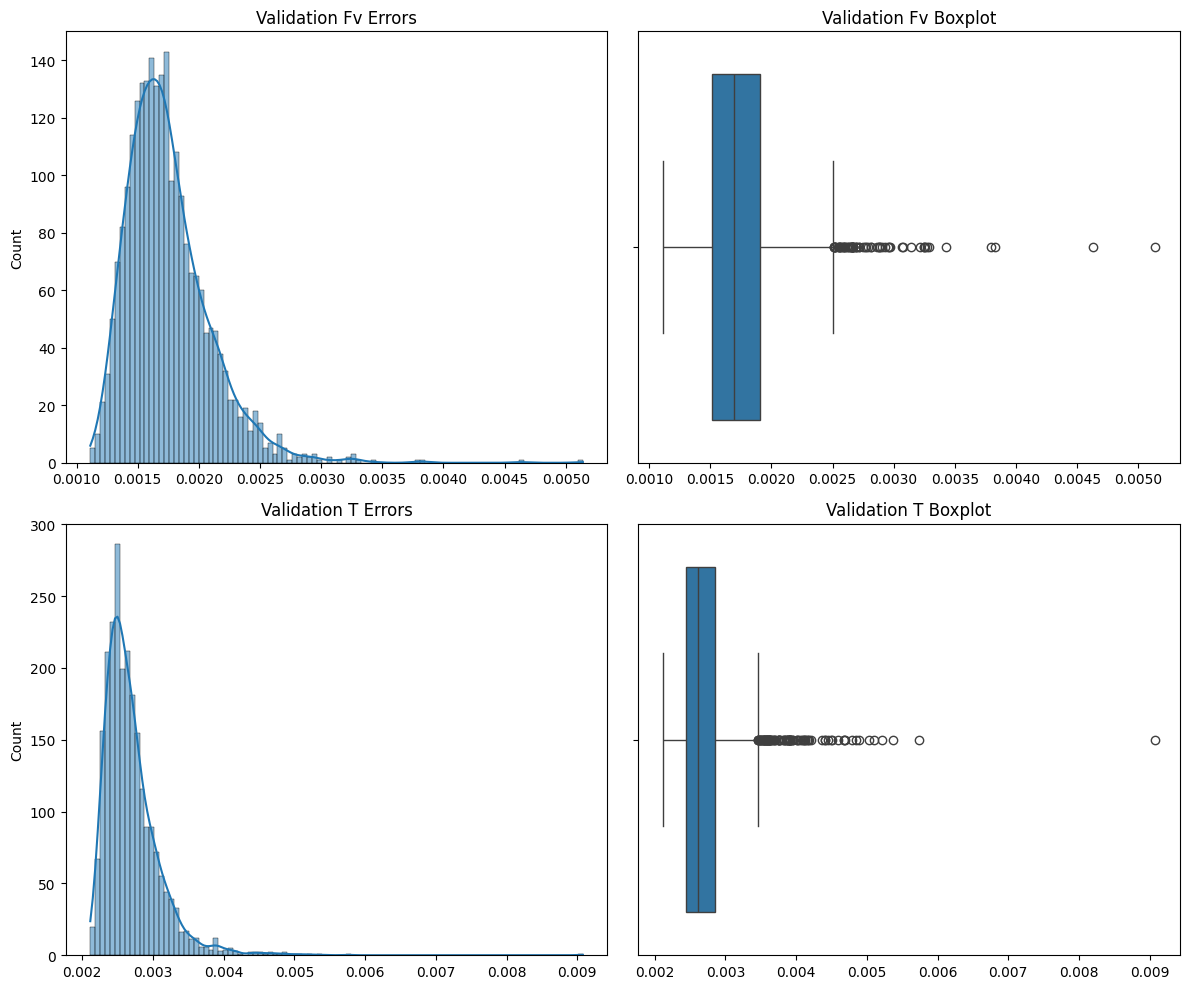

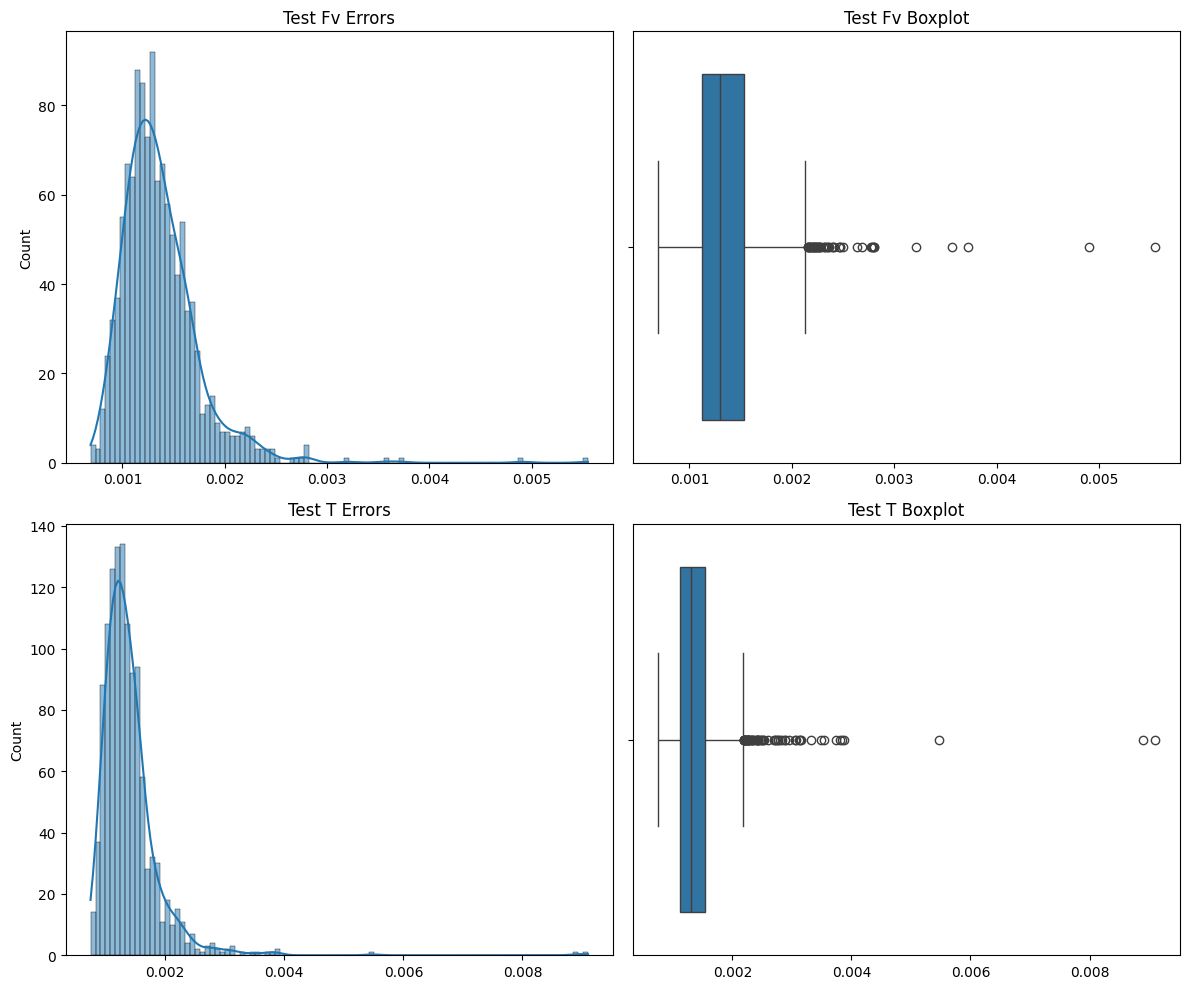

In [27]:
train_metrics = process_dataset(path_train, "train")
val_metrics = process_dataset(path_val, "val")
test_metrics = process_dataset(path_test, "test")

# Summary tables
summarize_metrics(train_metrics, "TRAIN")
summarize_metrics(val_metrics, "VAL")
summarize_metrics(test_metrics, "TEST")



# Optional: visualize full error distributions
plot_error_distributions(train_metrics, "Train")
plot_error_distributions(val_metrics, "Validation")
plot_error_distributions(test_metrics, "Test")


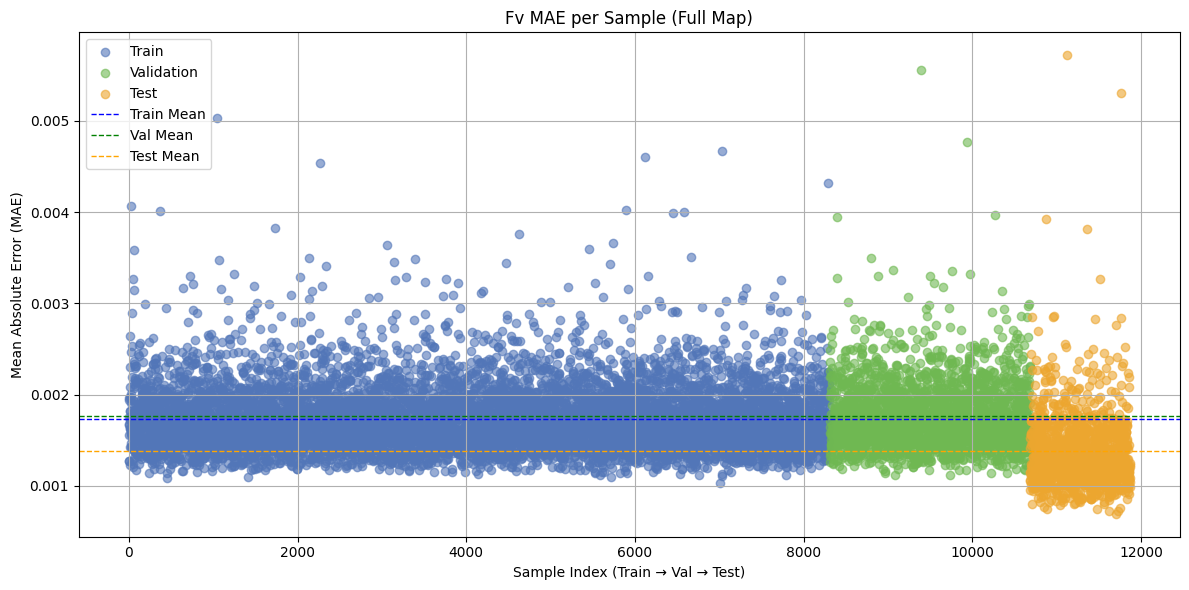

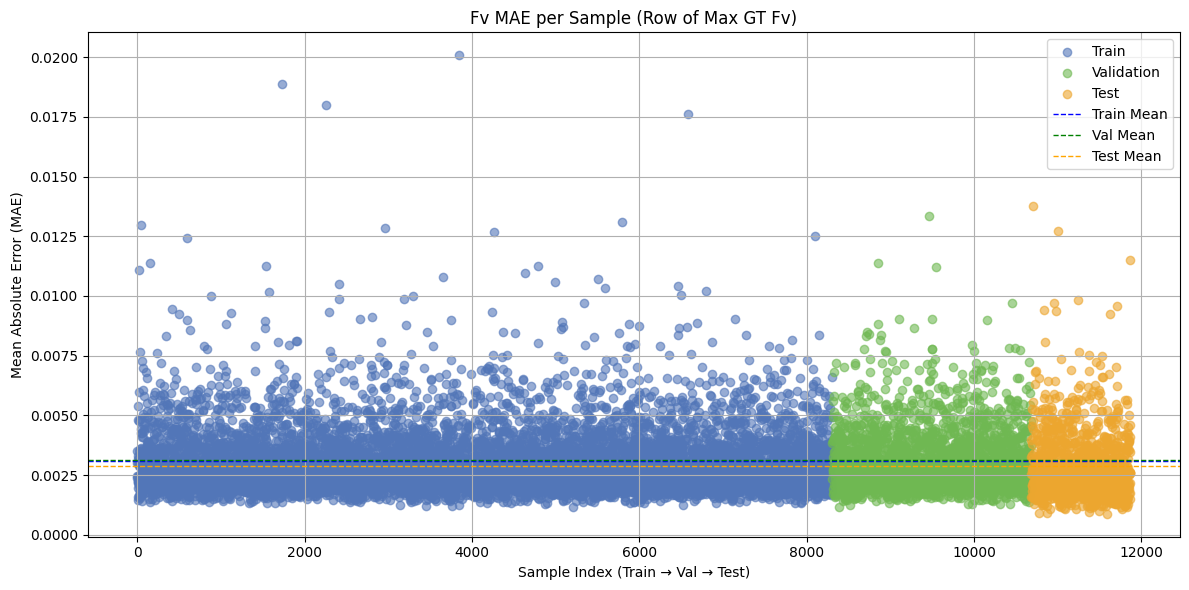

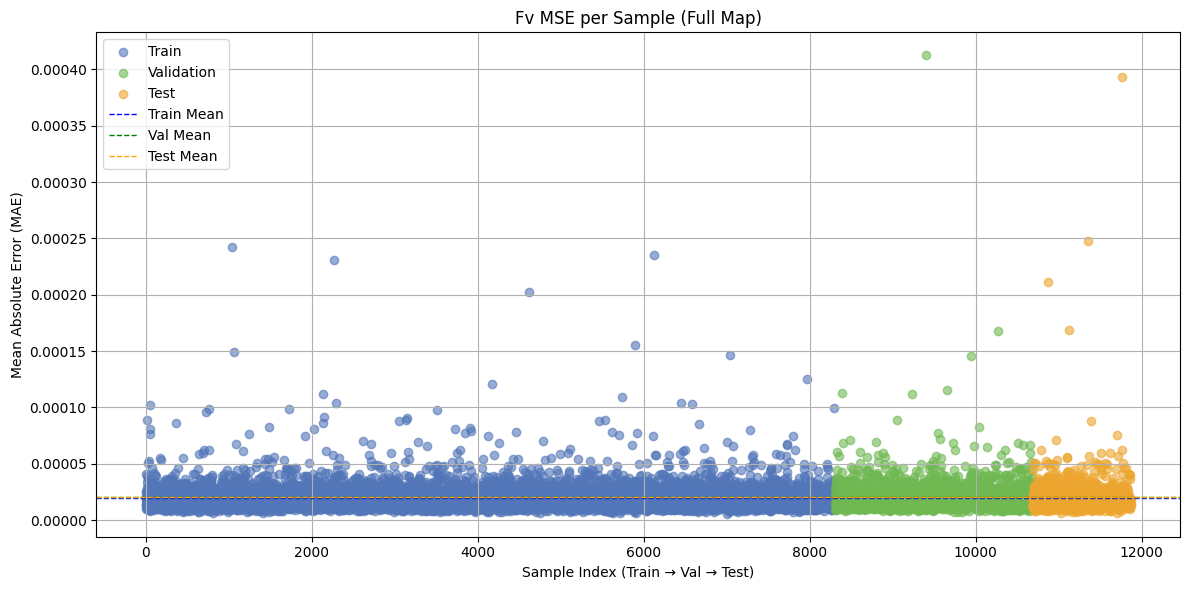

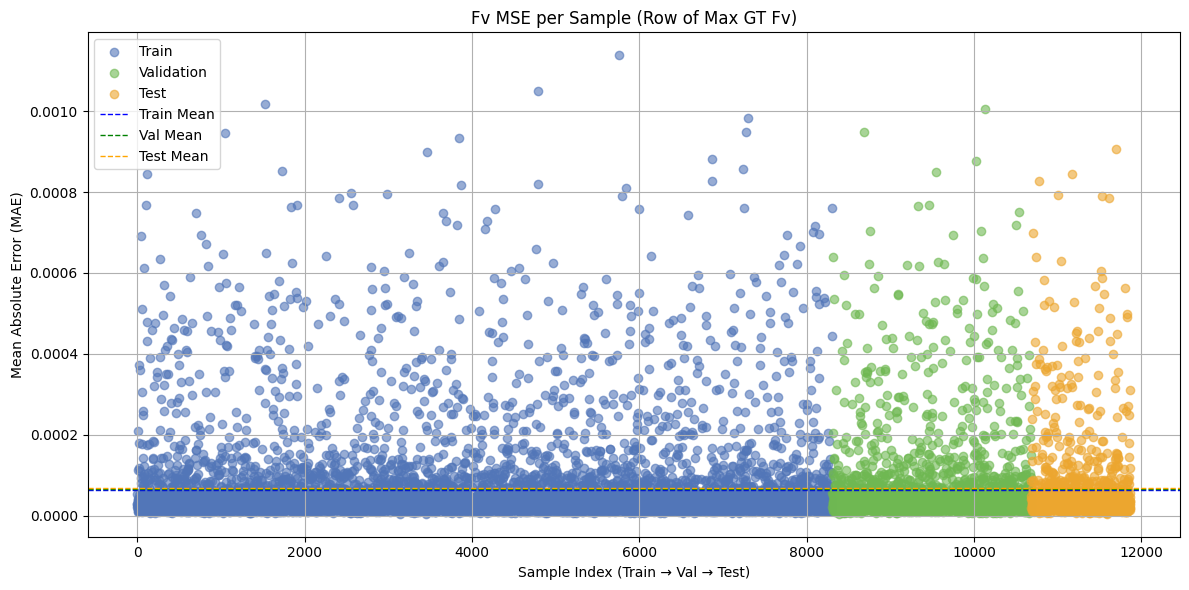

In [67]:
# Extract per-sample MAEs (index 1) from full map metrics
train_mae_fv = [metrics[1] for metrics in train_metrics['fv_full']]
val_mae_fv = [metrics[1] for metrics in val_metrics['fv_full']]
test_mae_fv = [metrics[1] for metrics in test_metrics['fv_full']]
plot_mae_dotplot(train_mae_fv, val_mae_fv, test_mae_fv, title="Fv MAE per Sample (Full Map)")

# Extract per-sample MAEs (index 1) from row-of-interest metrics
train_mae_row_fv = [metrics[1] for metrics in train_metrics['fv_row']]
val_mae_row_fv = [metrics[1] for metrics in val_metrics['fv_row']]
test_mae_row_fv = [metrics[1] for metrics in test_metrics['fv_row']]
plot_mae_dotplot(train_mae_row_fv, val_mae_row_fv, test_mae_row_fv, title="Fv MAE per Sample (Row of Max GT Fv)")

# Extract per-sample MSEs (index 0) from full map metrics 
train_mse_fv = [metrics[0] for metrics in train_metrics['fv_full']] 
val_mse_fv = [metrics[0] for metrics in val_metrics['fv_full']] 
test_mse_fv = [metrics[0] for metrics in test_metrics['fv_full']] 

plot_mae_dotplot(train_mse_fv, val_mse_fv, test_mse_fv, title="Fv MSE per Sample (Full Map)")

# Extract per-sample MSEs (index 0) from row-of-interest metrics 
train_mse_row_fv = [metrics[0] for metrics in train_metrics['fv_row']] 
val_mse_row_fv = [metrics[0] for metrics in val_metrics['fv_row']] 
test_mse_row_fv = [metrics[0] for metrics in test_metrics['fv_row']] 

plot_mae_dotplot(train_mse_row_fv, val_mse_row_fv, test_mse_row_fv, title="Fv MSE per Sample (Row of Max GT Fv)")

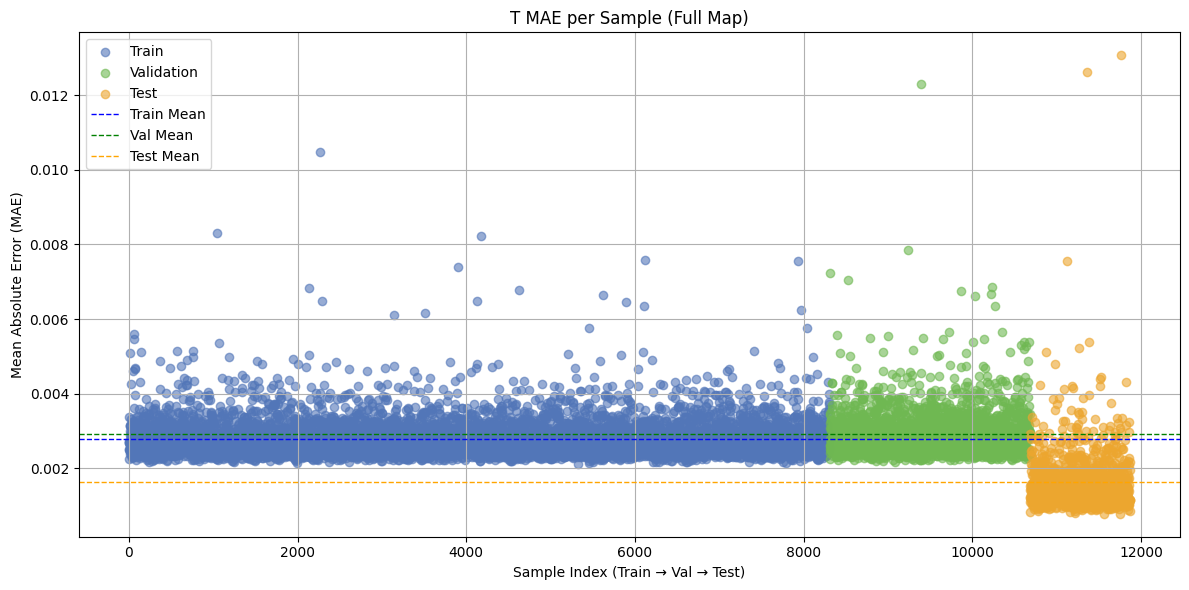

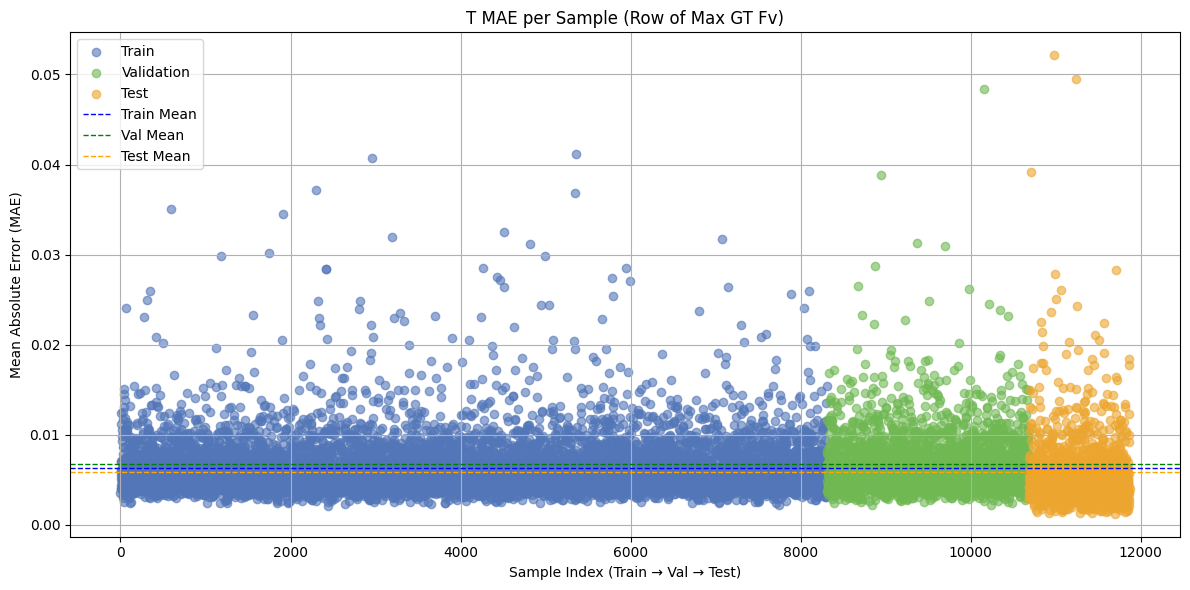

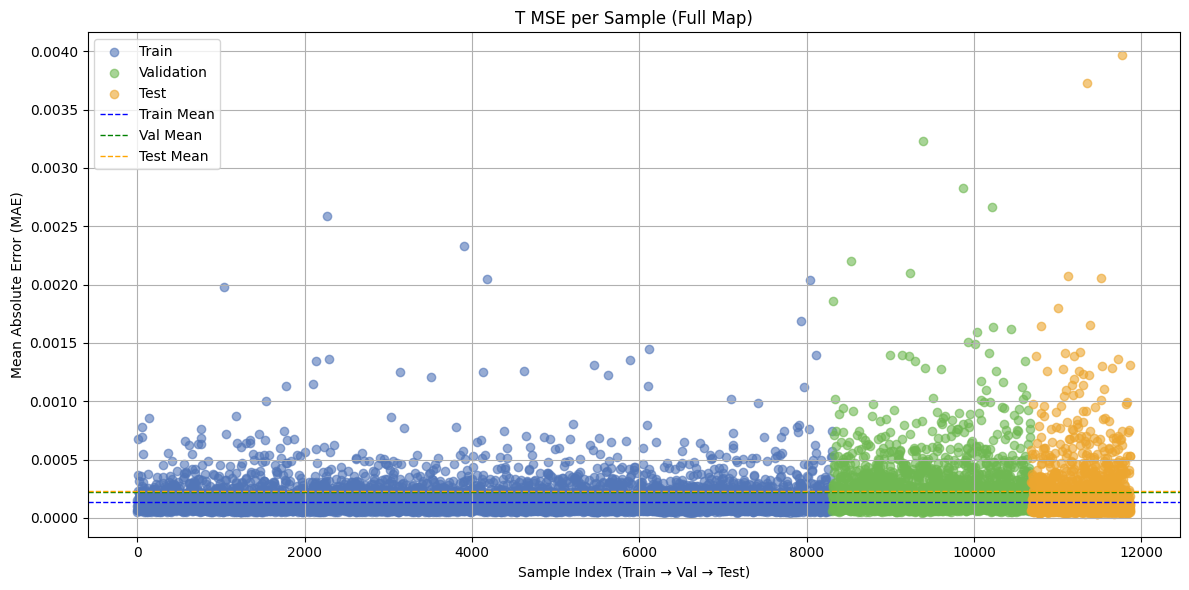

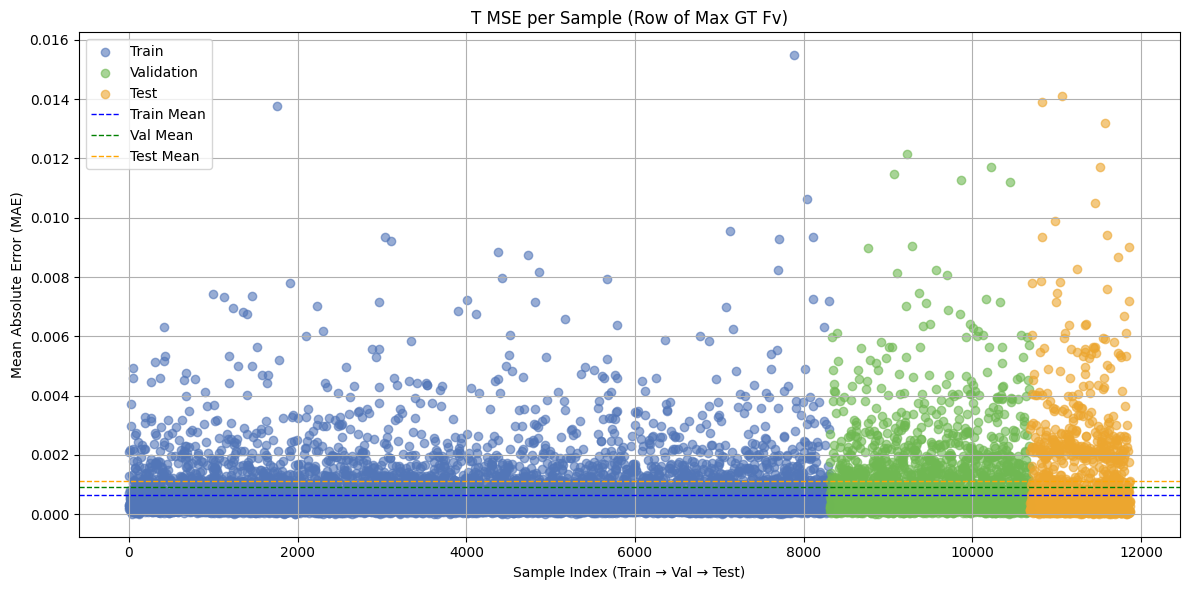

In [68]:
# Extract per-sample MAEs (index 1) from full map metrics Temperature
train_mae_t = [metrics[1] for metrics in train_metrics['t_full']]
val_mae_t = [metrics[1] for metrics in val_metrics['t_full']]
test_mae_t = [metrics[1] for metrics in test_metrics['t_full']]
plot_mae_dotplot(train_mae_t, val_mae_t, test_mae_t, title="T MAE per Sample (Full Map)")

# Extract per-sample MAEs (index 1) from row-of-interest metrics
train_mae_row_t = [metrics[1] for metrics in train_metrics['t_row']]
val_mae_row_t = [metrics[1] for metrics in val_metrics['t_row']]
test_mae_row_t = [metrics[1] for metrics in test_metrics['t_row']]
plot_mae_dotplot(train_mae_row_t, val_mae_row_t, test_mae_row_t, title="T MAE per Sample (Row of Max GT Fv)")

# Extract per-sample MSEs (index 0) from full map metrics 
train_mse_t = [metrics[0] for metrics in train_metrics['t_full']] 
val_mse_t = [metrics[0] for metrics in val_metrics['t_full']] 
test_mse_t = [metrics[0] for metrics in test_metrics['t_full']] 

plot_mae_dotplot(train_mse_t, val_mse_t, test_mse_t, title="T MSE per Sample (Full Map)")

# Extract per-sample MSEs (index 0) from row-of-interest metrics 
train_mse_row_t = [metrics[0] for metrics in train_metrics['t_row']] 
val_mse_row_t = [metrics[0] for metrics in val_metrics['t_row']] 
test_mse_row_t = [metrics[0] for metrics in test_metrics['t_row']] 

plot_mae_dotplot(train_mse_row_t, val_mse_row_t, test_mse_row_t, title="T MSE per Sample (Row of Max GT Fv)")

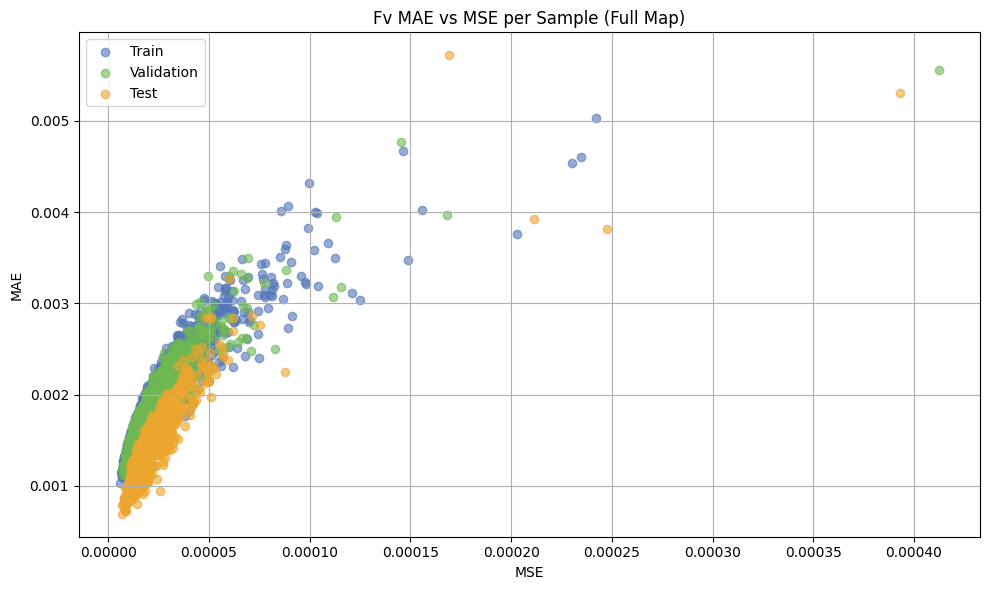

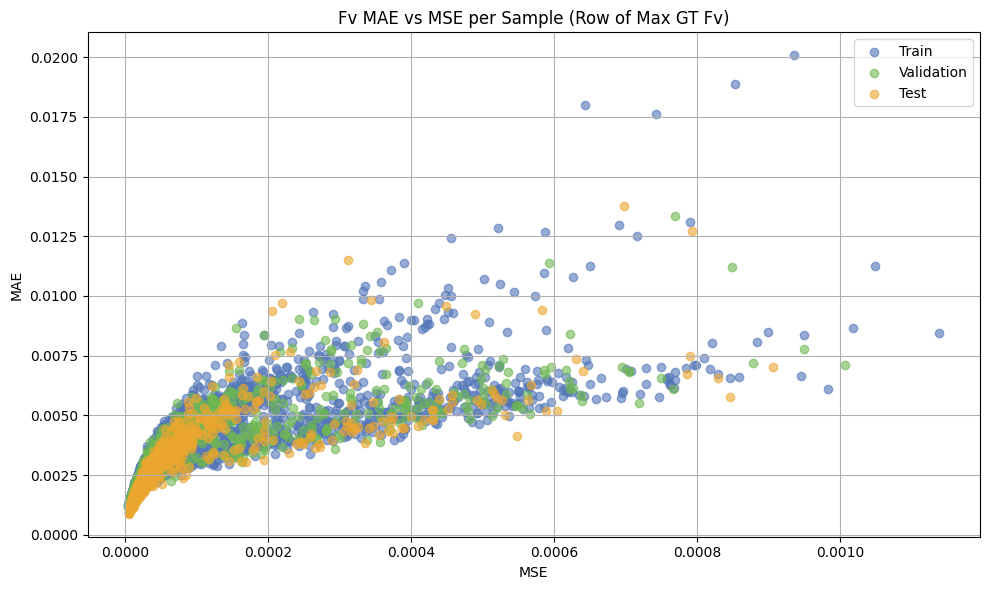

In [70]:
# Scatter plot of MAE vs MSE for full map metrics
def plot_mae_vs_mse_scatter(mae_train, mse_train, mae_val, mse_val, mae_test=None, mse_test=None, title="MAE vs MSE per Sample"):
    plt.figure(figsize=(10, 6))

    plt.scatter(mse_train, mae_train, label='Train', color='#5276B8', alpha=0.6)
    plt.scatter(mse_val, mae_val, label='Validation', color='#6FB852', alpha=0.6)
    if mae_test is not None and mse_test is not None:
        plt.scatter(mse_test, mae_test, label='Test', color='#ECA62F', alpha=0.6)

    plt.xlabel("MSE")
    plt.ylabel("MAE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_mae_vs_mse_scatter(
    train_mae_fv, train_mse_fv,
    val_mae_fv, val_mse_fv, test_mae_fv, test_mse_fv,
    title="Fv MAE vs MSE per Sample (Full Map)"
)
plot_mae_vs_mse_scatter(
    train_mae_row_fv, train_mse_row_fv,
    val_mae_row_fv, val_mse_row_fv, test_mae_row_fv, test_mse_row_fv,
    title="Fv MAE vs MSE per Sample (Row of Max GT Fv)"
)



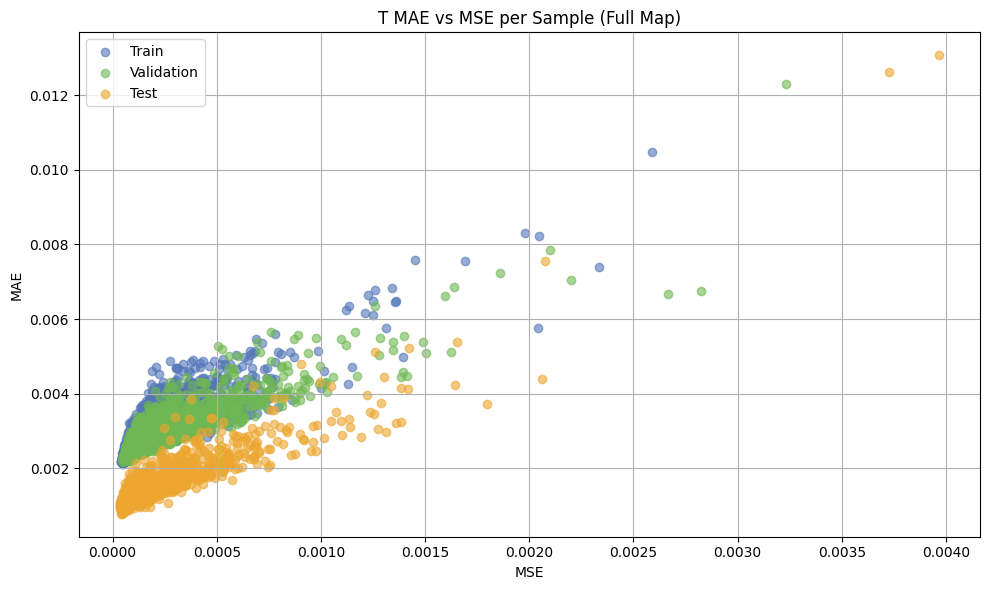

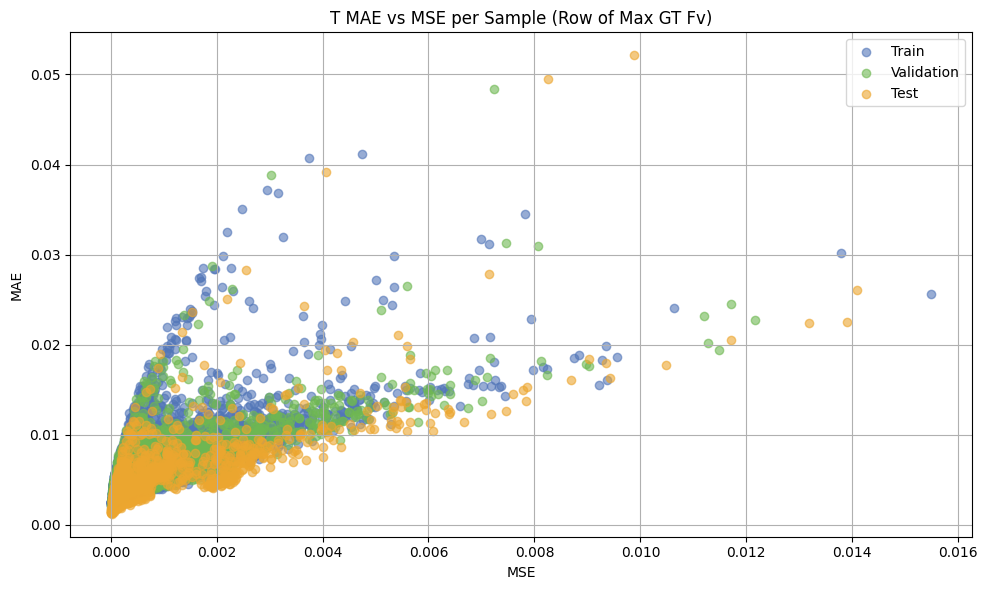

In [71]:
# Scatter plot of MAE vs MSE for full map metrics T
def plot_mae_vs_mse_scatter(mae_train, mse_train, mae_val, mse_val, mae_test=None, mse_test=None, title="MAE vs MSE per Sample"):
    plt.figure(figsize=(10, 6))

    plt.scatter(mse_train, mae_train, label='Train', color='#5276B8', alpha=0.6)
    plt.scatter(mse_val, mae_val, label='Validation', color='#6FB852', alpha=0.6)
    if mae_test is not None and mse_test is not None:
        plt.scatter(mse_test, mae_test, label='Test', color='#ECA62F', alpha=0.6)

    plt.xlabel("MSE")
    plt.ylabel("MAE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_mae_vs_mse_scatter(
    train_mae_t, train_mse_t,
    val_mae_t, val_mse_t,  test_mae_t, test_mse_t,
    title="T MAE vs MSE per Sample (Full Map)"
)
plot_mae_vs_mse_scatter(
    train_mae_row_t, train_mse_row_t,
    val_mae_row_t, val_mse_row_t, test_mae_row_t, test_mse_row_t,
    title="T MAE vs MSE per Sample (Row of Max GT Fv)"
)

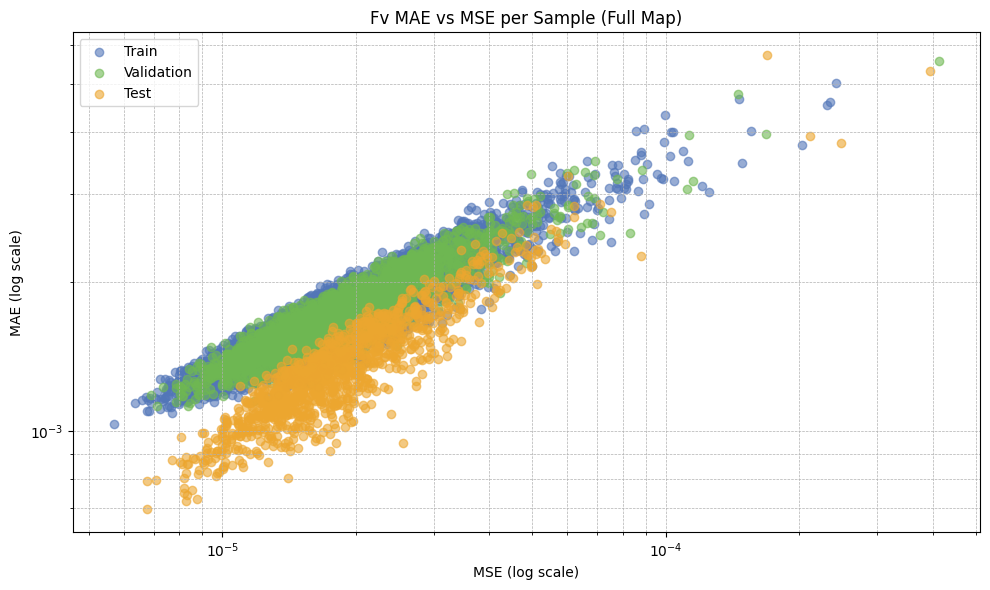

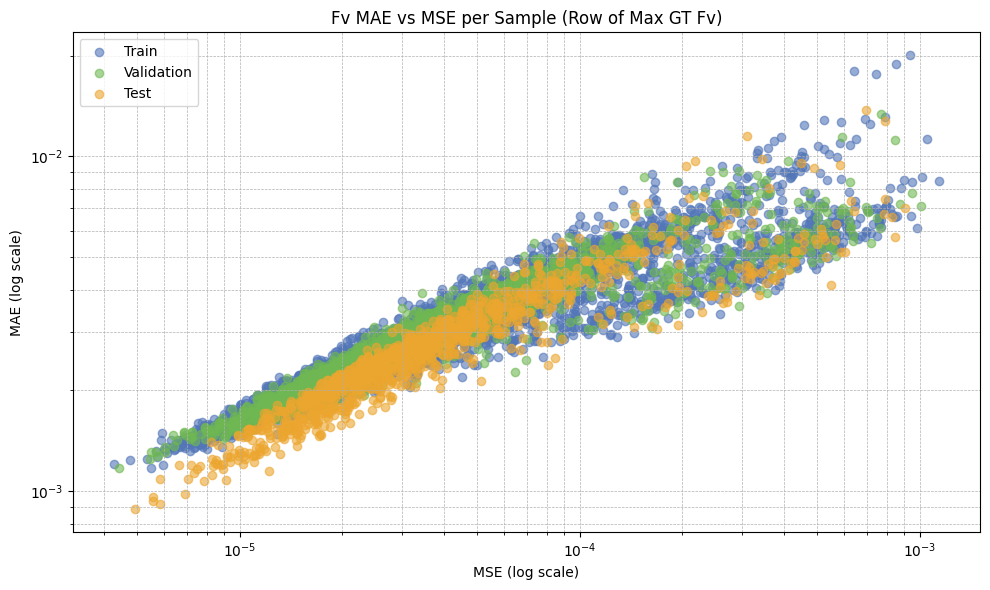

In [73]:
def plot_mae_vs_mse_scatter_log(mae_train, mse_train, mae_val, mse_val, mae_test=None, mse_test=None, title="MAE vs MSE per Sample (Log Scale)"):
    plt.figure(figsize=(10, 6))

    plt.scatter(mse_train, mae_train, label='Train', color='#5276B8', alpha=0.6)
    plt.scatter(mse_val, mae_val, label='Validation', color='#6FB852', alpha=0.6)
    if mae_test is not None and mse_test is not None:
        plt.scatter(mse_test, mae_test, label='Test', color='#ECA62F', alpha=0.6)

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel("MSE (log scale)")
    plt.ylabel("MAE (log scale)")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

plot_mae_vs_mse_scatter_log(
train_mae_fv, train_mse_fv,
val_mae_fv, val_mse_fv, test_mae_fv, test_mse_fv,
title="Fv MAE vs MSE per Sample (Full Map)"
)
plot_mae_vs_mse_scatter_log(
    train_mae_row_fv, train_mse_row_fv,
    val_mae_row_fv, val_mse_row_fv, test_mae_row_fv, test_mse_row_fv,
    title="Fv MAE vs MSE per Sample (Row of Max GT Fv)"
)

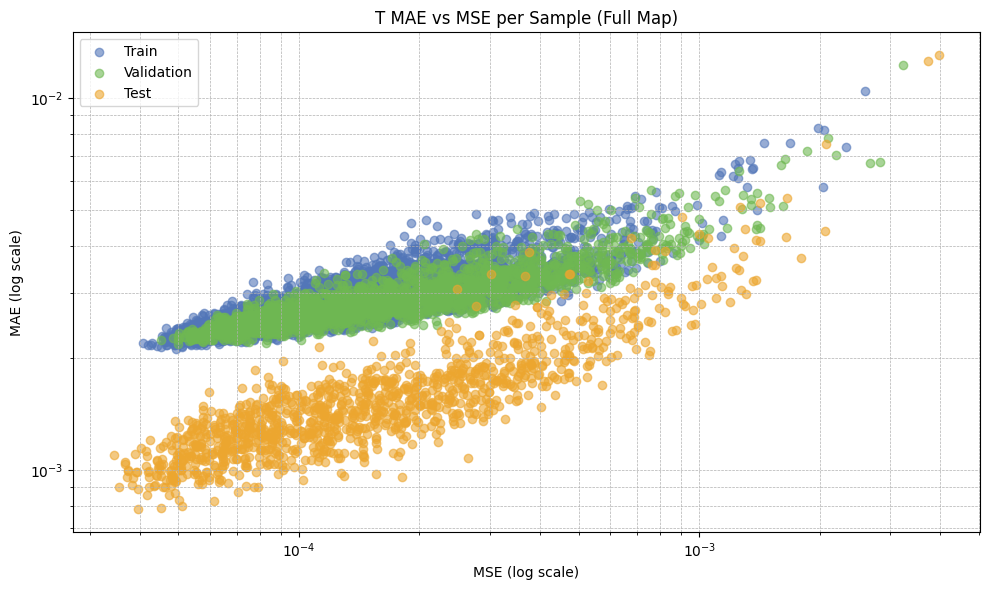

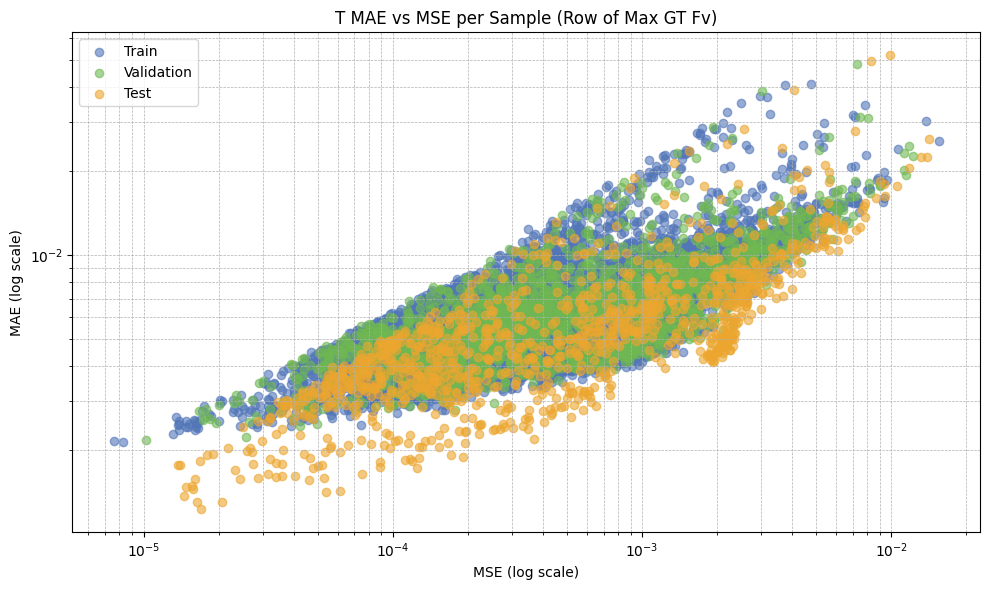

In [74]:
#T
def plot_mae_vs_mse_scatter_log(mae_train, mse_train, mae_val, mse_val, mae_test=None, mse_test=None, title="MAE vs MSE per Sample (Log Scale)"):
    plt.figure(figsize=(10, 6))

    plt.scatter(mse_train, mae_train, label='Train', color='#5276B8', alpha=0.6)
    plt.scatter(mse_val, mae_val, label='Validation', color='#6FB852', alpha=0.6)
    if mae_test is not None and mse_test is not None:
        plt.scatter(mse_test, mae_test, label='Test', color='#ECA62F', alpha=0.6)

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel("MSE (log scale)")
    plt.ylabel("MAE (log scale)")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

plot_mae_vs_mse_scatter_log(
train_mae_t, train_mse_t,
val_mae_t, val_mse_t, test_mae_t, test_mse_t,
title="T MAE vs MSE per Sample (Full Map)"
)
plot_mae_vs_mse_scatter_log(
    train_mae_row_t, train_mse_row_t,
    val_mae_row_t, val_mse_row_t, test_mae_row_t, test_mse_row_t,
    title="T MAE vs MSE per Sample (Row of Max GT Fv)"
)

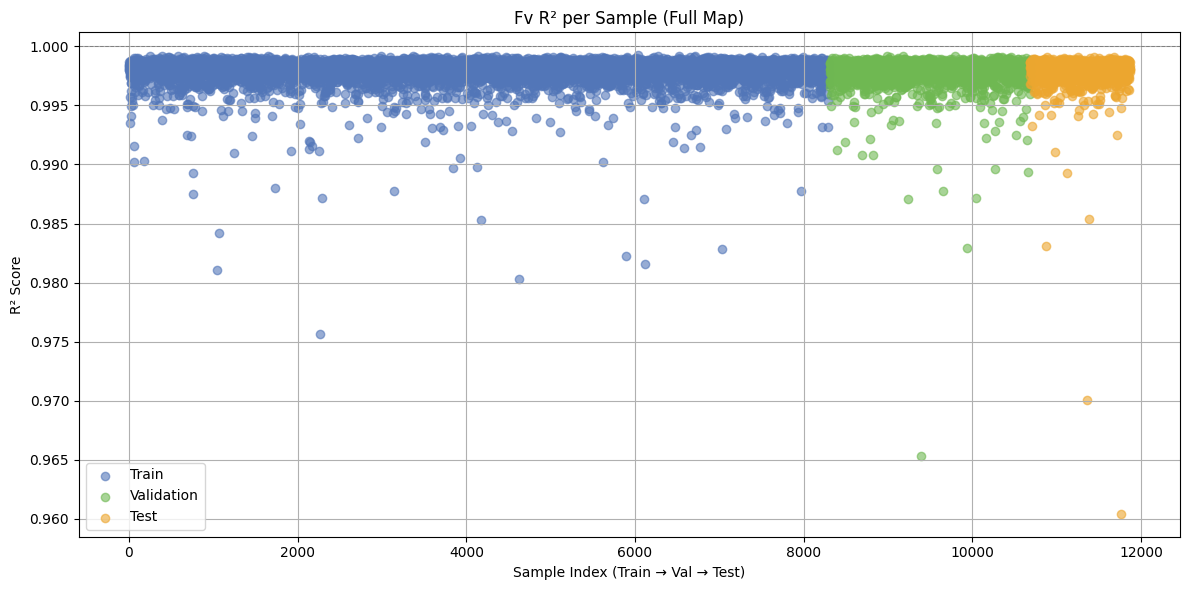

In [75]:
#| Visualization           | Purpose                       | Use When You Want To...                          |
#| ----------------------- | ----------------------------- | ------------------------------------------------ |
#| Dot Plot (per sample)   | Outlier detection             | Spot samples with low R²                         |
#| Violin Plot             | Distribution comparison       | Summarize & compare R² distributions across sets |
#| Pred vs GT Scatter Plot | Regression quality (1 sample) | Inspect prediction quality in detail             |


# Dot Plot of R² Scores (Per Sample)
def plot_r2_dotplot(r2_train, r2_val, r2_test=None, title="R² per Sample"):
    plt.figure(figsize=(12, 6))
    plt.scatter(range(len(r2_train)), r2_train, label='Train', color='#5276B8', alpha=0.6)
    plt.scatter(np.arange(len(r2_val)) + len(r2_train), r2_val, label='Validation', color='#6FB852', alpha=0.6)
    if r2_test is not None:
        plt.scatter(np.arange(len(r2_test)) + len(r2_train) + len(r2_val), r2_test, label='Test', color='#ECA62F', alpha=0.6)

    plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.7)
    plt.ylabel("R² Score")
    plt.xlabel("Sample Index (Train → Val → Test)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

train_r2_fv = [metrics[3] for metrics in train_metrics['fv_full']]
val_r2_fv = [metrics[3] for metrics in val_metrics['fv_full']]
test_r2_fv = [metrics[3] for metrics in test_metrics['fv_full']]

plot_r2_dotplot(train_r2_fv, val_r2_fv, test_r2_fv, title="Fv R² per Sample (Full Map)")


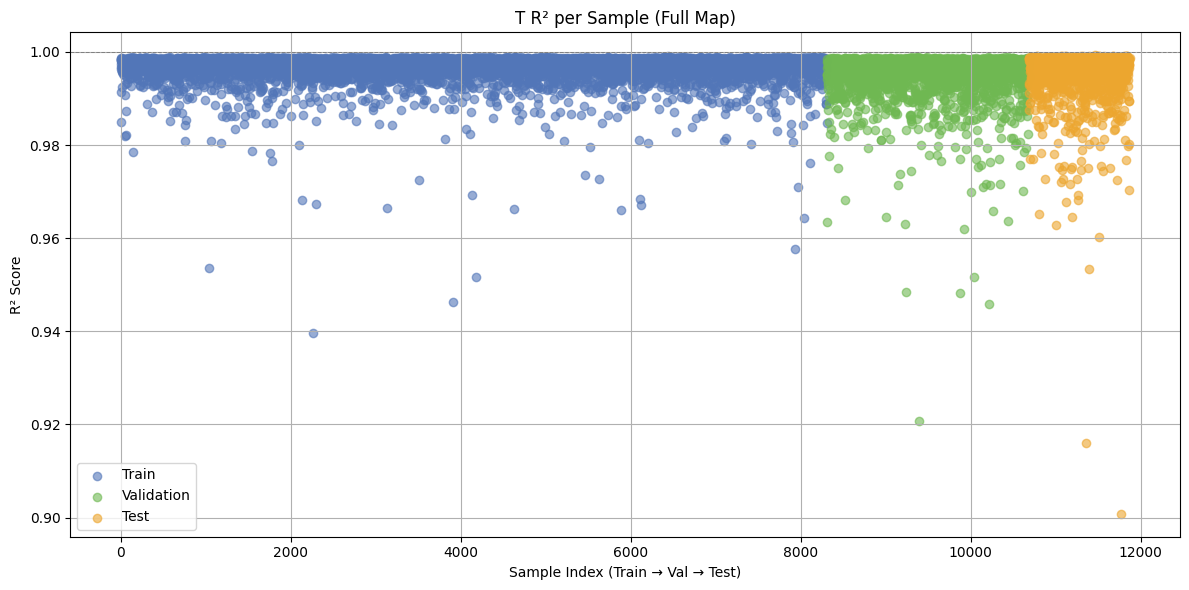

In [76]:
#T
#| Visualization           | Purpose                       | Use When You Want To...                          |
#| ----------------------- | ----------------------------- | ------------------------------------------------ |
#| Dot Plot (per sample)   | Outlier detection             | Spot samples with low R²                         |
#| Violin Plot             | Distribution comparison       | Summarize & compare R² distributions across sets |
#| Pred vs GT Scatter Plot | Regression quality (1 sample) | Inspect prediction quality in detail             |


# Dot Plot of R² Scores (Per Sample)
def plot_r2_dotplot(r2_train, r2_val, r2_test=None, title="R² per Sample"):
    plt.figure(figsize=(12, 6))
    plt.scatter(range(len(r2_train)), r2_train, label='Train', color='#5276B8', alpha=0.6)
    plt.scatter(np.arange(len(r2_val)) + len(r2_train), r2_val, label='Validation', color='#6FB852', alpha=0.6)
    if r2_test is not None:
        plt.scatter(np.arange(len(r2_test)) + len(r2_train) + len(r2_val), r2_test, label='Test', color='#ECA62F', alpha=0.6)

    plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.7)
    plt.ylabel("R² Score")
    plt.xlabel("Sample Index (Train → Val → Test)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

train_r2_t = [metrics[3] for metrics in train_metrics['t_full']]
val_r2_t = [metrics[3] for metrics in val_metrics['t_full']]
test_r2_t = [metrics[3] for metrics in test_metrics['t_full']]

plot_r2_dotplot(train_r2_t, val_r2_t, test_r2_t, title="T R² per Sample (Full Map)")

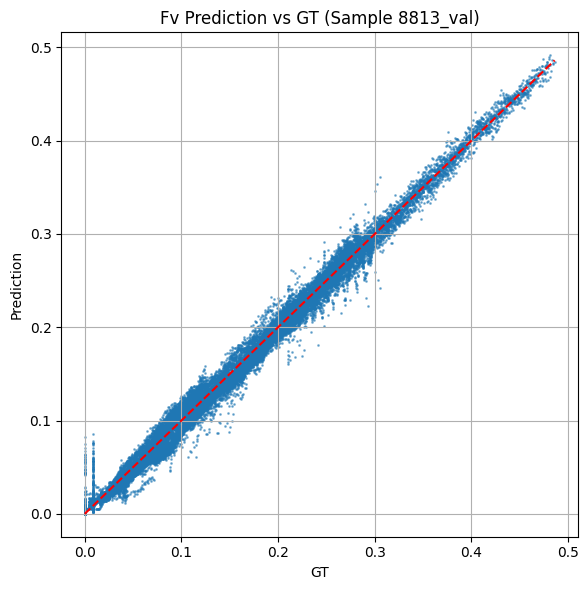

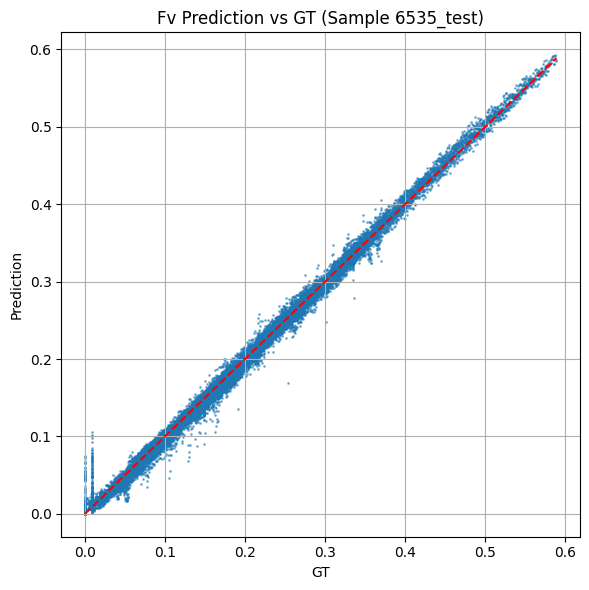

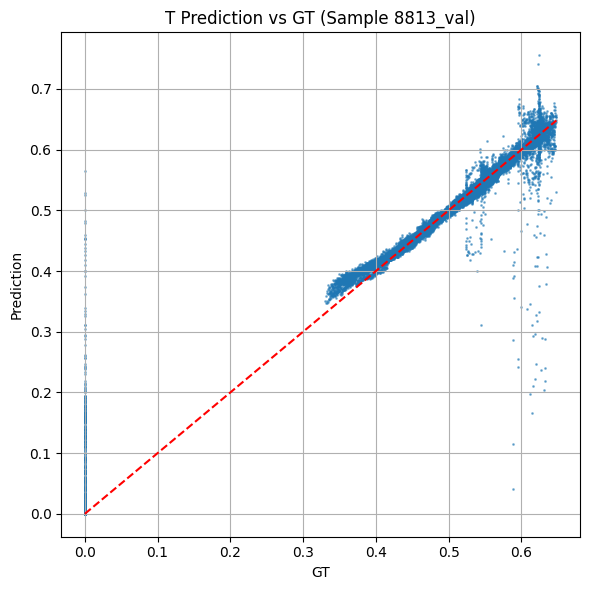

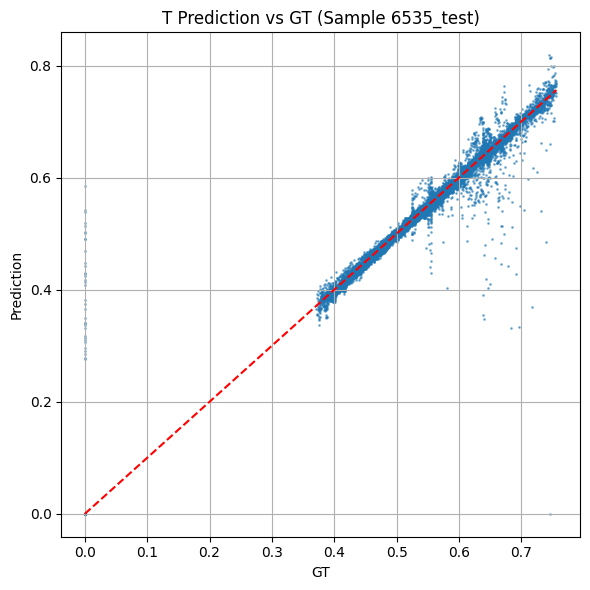

Looking at Sample 8813_val Indexes where gt_t is 0.5-0.6 and pred_t < 0.05: [1995]
0.000395 0.001383 
 0.000395 0.001399 
 0.000395 0.001731 
 0.000395 0.00142


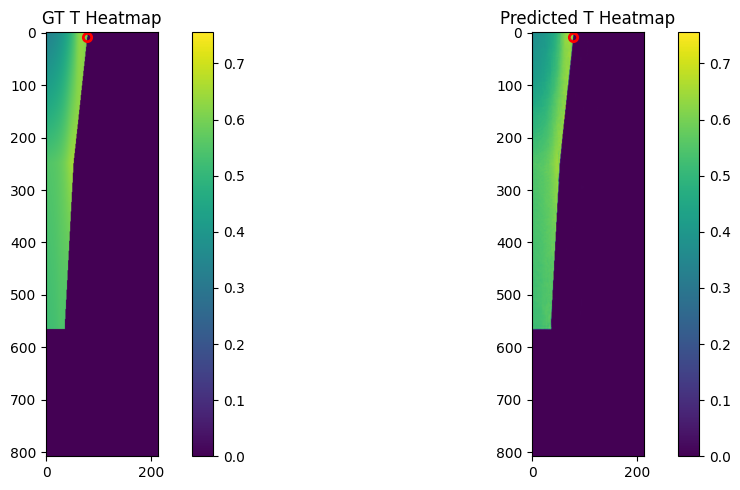

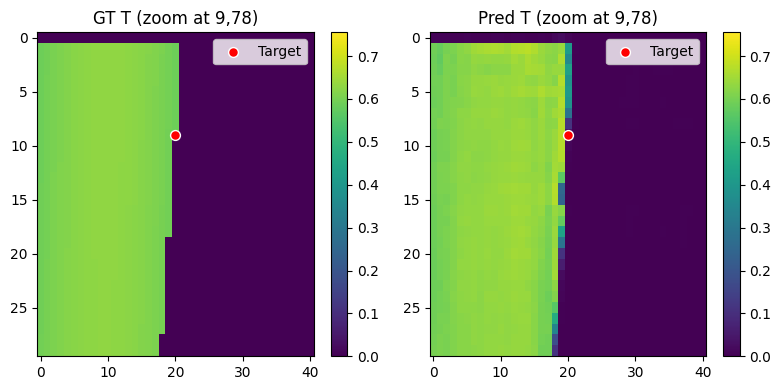

In [46]:
#see the regression quality directly for a specific sample - Scatter Plot: Predicted vs Ground Truth Values — Sample-Wise Insight
def plot_pred_vs_gt(gt, pred, title="Predicted vs Ground Truth", xlabel="GT", ylabel="Prediction"):
    plt.figure(figsize=(6, 6))
    plt.scatter(gt, pred, s=1, alpha=0.5)
    plt.plot([gt.min(), gt.max()], [gt.min(), gt.max()], 'r--')  # Ideal line
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

sample_id = "8813"
sample_id_test = "6535"
gt_fv_test = os.path.join(path_test, f"{sample_id_test}_gt_Fv_test.csv")
pred_fv_test = os.path.join(path_test, f"{sample_id_test}_pred_Fv_test.csv")
gt_t_test = os.path.join(path_test, f"{sample_id_test}_gt_T_test.csv")
pred_t_test = os.path.join(path_test, f"{sample_id_test}_pred_T_test.csv")
gt_fv = os.path.join(path_val, f"{sample_id}_gt_Fv_val.csv")
pred_fv = os.path.join(path_val, f"{sample_id}_pred_Fv_val.csv")
gt_t = os.path.join(path_val, f"{sample_id}_gt_T_val.csv")
pred_t = os.path.join(path_val, f"{sample_id}_pred_T_val.csv")
sample_stats = process_sample(gt_fv, pred_fv, gt_t, pred_t)
sample_stats_test = process_sample(gt_fv_test, pred_fv_test, gt_t_test, pred_t_test)
gt_Fv = sample_stats['full']['gt_fv']
pred_Fv = sample_stats['full']['pred_fv']
gt_Fv_test = sample_stats_test['full']['gt_fv']
pred_Fv_test = sample_stats_test['full']['pred_fv']
plot_pred_vs_gt(gt_Fv.flatten(), pred_Fv.flatten(), title=f"Fv Prediction vs GT (Sample {sample_id}_val)")
plot_pred_vs_gt(gt_Fv_test.flatten(), pred_Fv_test.flatten(), title=f"Fv Prediction vs GT (Sample {sample_id_test}_test)")
gt_t = sample_stats['full']['gt_t']
pred_t = sample_stats['full']['pred_t']
gt_t_test = sample_stats_test['full']['gt_t']
pred_t_test = sample_stats_test['full']['pred_t']
# Print the values
plot_pred_vs_gt(gt_t.flatten(), pred_t.flatten(), title=f"T Prediction vs GT (Sample {sample_id}_val)")
plot_pred_vs_gt(gt_t_test.flatten(), pred_t_test.flatten(), title=f"T Prediction vs GT (Sample {sample_id_test}_test)")
# Find indexes where gt_t is between 0.5 and 0.6
gt_mask = (gt_t >= 0.5) & (gt_t <= 0.6)
# Find indexes where pred_t at those locations is less than 0.05
pred_mask = pred_t < 0.05
# Combine both conditions
final_mask = gt_mask & pred_mask

# Get the indexes
indexes = np.where(final_mask)[0]
print(f"Looking at Sample {sample_id}_val Indexes where gt_t is 0.5-0.6 and pred_t < 0.05:", indexes)
#112722 112935 113148 113361
print(gt_t[112722], pred_t[112722],"\n",
      gt_t[112935], pred_t[112935],"\n",
      gt_t[113148], pred_t[113148],"\n",
      gt_t[113361], pred_t[113361])

import matplotlib.pyplot as plt
import numpy as np

# Assume you know the original shape, e.g. (H, W)
original_shape = (808,213)  # If gt_t is still 2D, else use (H, W) explicitly

# If gt_t is flattened, reshape it:
gt_t_2d = gt_t.reshape(original_shape)
pred_t_2d = pred_t.reshape(original_shape)
# Compute global min and max for both maps
vmin = min(gt_t_2d.min(), pred_t_2d.min())
vmax = max(gt_t_2d.max(), pred_t_2d.max())

# Convert flat indexes to 2D coordinates
highlight_coords = [np.unravel_index(idx, original_shape) for idx in indexes]

# Plot GT heatmap
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(gt_t_2d, cmap='viridis', vmin=vmin, vmax=vmax)
plt.title("GT T Heatmap")
for y, x in highlight_coords:
    plt.plot(x, y, 'ro', markersize=6, markeredgewidth=2, markerfacecolor='none')
plt.colorbar()

# Plot Prediction heatmap
plt.subplot(1, 2, 2)
plt.imshow(pred_t_2d, cmap='viridis', vmin=vmin, vmax=vmax)
plt.title("Predicted T Heatmap")
for y, x in highlight_coords:
    plt.plot(x, y, 'ro', markersize=6, markeredgewidth=2, markerfacecolor='none')
plt.colorbar()

plt.tight_layout()
plt.show()

window = 20  # window size (half-width)
for idx in indexes:
    y, x = np.unravel_index(idx, original_shape)
    # Define window bounds, making sure not to go out of bounds
    y_min = max(y - window, 0)
    y_max = min(y + window + 1, original_shape[0])
    x_min = max(x - window, 0)
    x_max = min(x + window + 1, original_shape[1])

    # Crop the regions
    gt_crop = gt_t_2d[y_min:y_max, x_min:x_max]
    pred_crop = pred_t_2d[y_min:y_max, x_min:x_max]

    # Plot
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(gt_crop, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title(f"GT T (zoom at {y},{x})")
    plt.colorbar()
    plt.scatter(x - x_min, y - y_min, color='red', s=50, edgecolors='white', label='Target')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.imshow(pred_crop, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title(f"Pred T (zoom at {y},{x})")
    plt.colorbar()
    plt.scatter(x - x_min, y - y_min, color='red', s=50, edgecolors='white', label='Target')
    plt.legend()

    plt.tight_layout()
    plt.show()





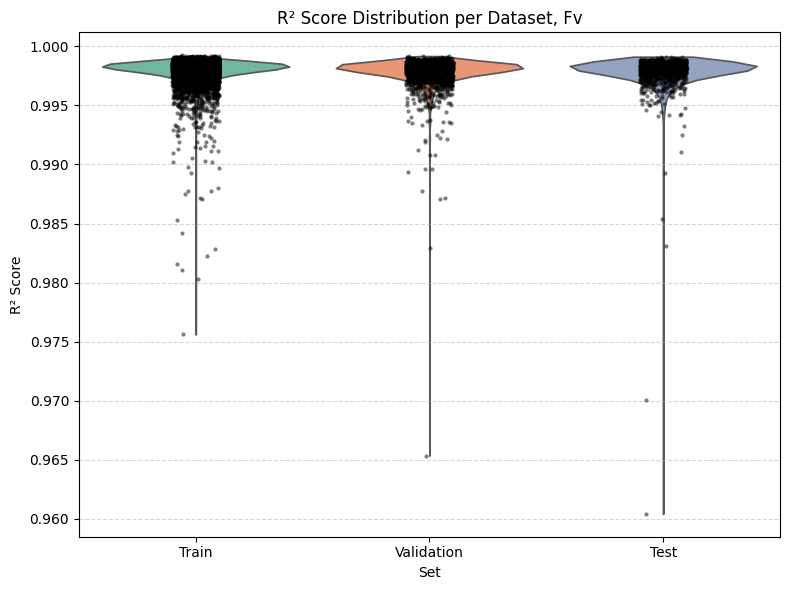

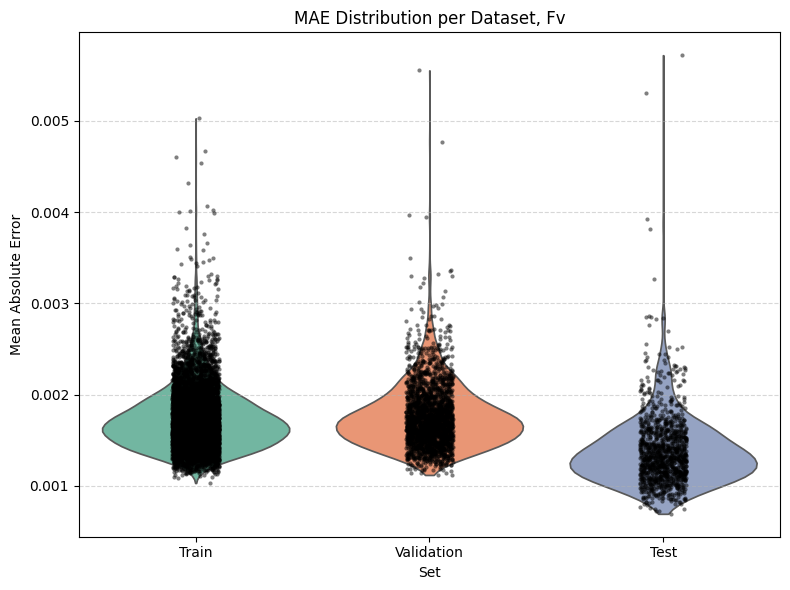

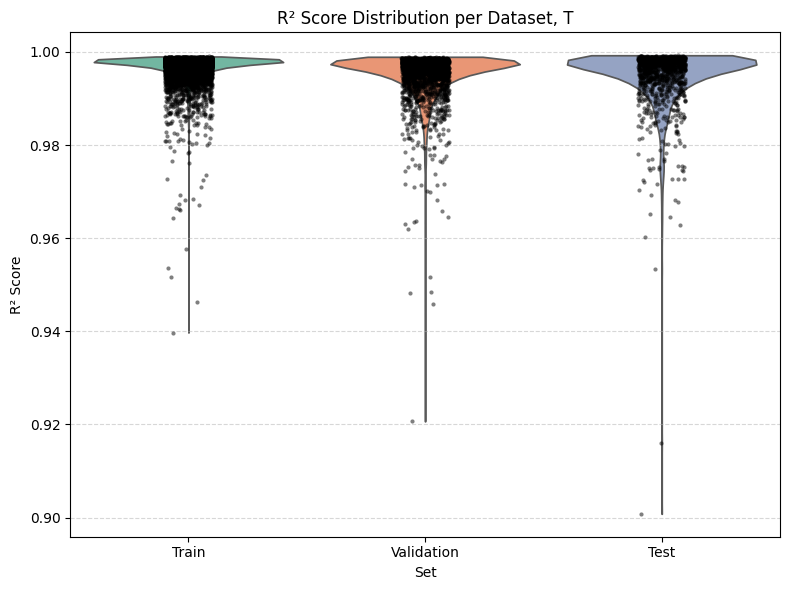

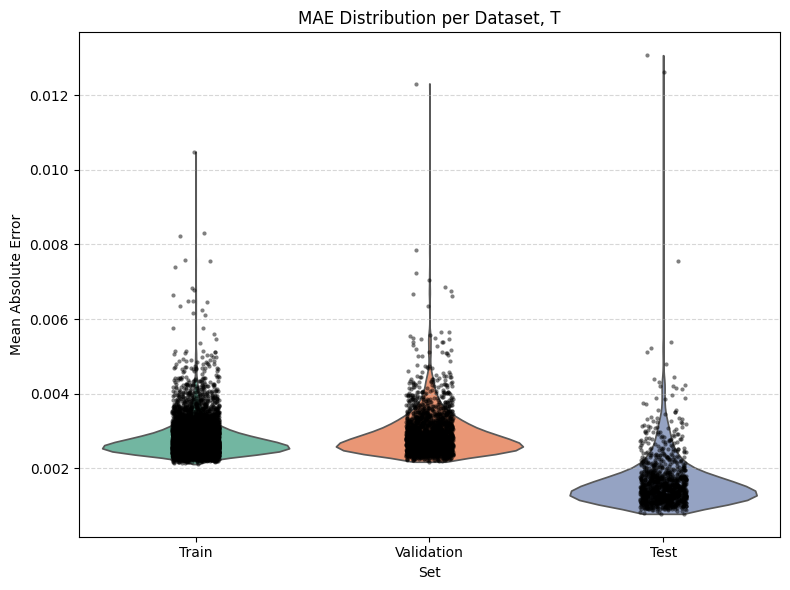

In [82]:
#fig5a fig5b
def plot_violin_dot_combined(metric_train, metric_val, metric_test=None, title="Metric Distribution", ylabel="Metric", save_path=None):
    # Assemble DataFrame
    data = []
    data += [(x, 'Train') for x in metric_train]
    data += [(x, 'Validation') for x in metric_val]
    if metric_test is not None:
        data += [(x, 'Test') for x in metric_test]

    df = pd.DataFrame(data, columns=["Value", "Set"])

    plt.figure(figsize=(8, 6))
    
    # Violin plot
    sns.violinplot(x="Set", y="Value", data=df, inner=None, palette="Set2", cut=0, hue="Set")
    
    # Dot overlay
    sns.stripplot(x="Set", y="Value", data=df, color='black', size=3, alpha=0.5, jitter=True)

    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

plot_violin_dot_combined(
    train_r2_fv, val_r2_fv, test_r2_fv,
    title="R² Score Distribution per Dataset, Fv",
    ylabel="R² Score"
)
plot_violin_dot_combined(
    train_mae_fv, val_mae_fv, test_mae_fv,
    title="MAE Distribution per Dataset, Fv",
    ylabel="Mean Absolute Error"
)
plot_violin_dot_combined(
    train_r2_t, val_r2_t, test_r2_t,
    title="R² Score Distribution per Dataset, T",
    ylabel="R² Score"
)
plot_violin_dot_combined(
    train_mae_t, val_mae_t, test_mae_t,
    title="MAE Distribution per Dataset, T",
    ylabel="Mean Absolute Error"
)

In [65]:
#plot smooth loss

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# def moving_average(data, window_size=10):
#     return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# === Step 1: Load Excel Data ===
file_path = os.path.join(path_all, 'loss.xlsx')
df = pd.read_excel(file_path)

# Assuming columns are named 'train_loss' and 'val_loss' (adjust if needed)
train_loss = df['train'].values
val_loss = df['val'].values
val_loss_smooth = df['val_smooth'].values

# === Step 2: Smooth with Moving Average ===
# window_size = 5
# train_smoothed = moving_average(train_loss, window_size)
# val_smoothed = moving_average(val_loss, window_size)
# epochs = np.arange(len(train_smoothed)) + window_size - 1  # shift for alignment
epochs = np.arange(len(train_loss))
test_loss = 0.0001267

# === Step 3A: Plot ONLY Smoothed ===
plt.figure(figsize=(10, 6))
plt.axhline(y=test_loss, color='red', linestyle='--', label=f'Test Loss: {test_loss:.8f}')
plt.plot(epochs, train_loss, label='Train Loss (smoothed)', color='blue')
plt.plot(epochs, val_loss_smooth, label='Val Loss (smoothed)', color='orange', alpha=0.8)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Smoothed Loss Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path_all, 'smoothed_val_loss.png'), dpi=300)
plt.ylim(0, 0.005)
plt.savefig(os.path.join(path_all, 'smoothed_val_loss_zoom.png'), dpi=300) 
plt.close()

# # === Step 3B: Plot Smoothed + Faint Original ===
# plt.figure(figsize=(10, 6))
# # plt.plot(train_loss, label='Train Loss (original)', color='blue', alpha=0.2)
# plt.plot(val_loss, label='Val Loss (original)', color='orange', alpha=0.2)
# plt.plot(epochs, train_loss, label='Train Loss (smoothed)', color='blue')
# plt.plot(epochs, val_loss_smooth, label='Val Loss (smoothed)', color='orange')
# plt.axhline(y=test_loss, color='red', linestyle='--', label=f'Test Loss: {test_loss:.8f}')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Loss Curves (Original + Smoothed)')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.savefig(os.path.join(path_all, 'smoothed_loss_with_original.png'), dpi=300)
# plt.close()
